# 🌙 MESA ECG Sleep Stage Classification — **LOCAL VERSION**

## Full Pipeline
```
MESA EDF files
     ↓  [Cell 2]  Imports & config  (update EDF_DIR / ANNOT_DIR)
     ↓  [Cell 3]  Load ECG + annotations → per-class lists
     ↓  [Cell 4]  Augmentation (min-class ×1.1, equalise all)
     ↓  [Cell 5]  Stratified 80 / 10 / 10 split
     ↓  [Cell 6]  PyTorch Dataset + DataLoaders
     ↓  [Cell 7]  1D ResNet-34 model definition
     ↓  [Cell 8]  (Optional) Load pretrained ECG weights
     ↓  [Cell 9]  Training loop (with tqdm + checkpoint)
     ↓  [Cell 10] Training curves plot
     ↓  [Cell 11] Test evaluation + confusion matrix
     ↓  [Cell 12] Save model locally (no browser download needed)
```

**Classes:** Wake (0) · N1 (1) · N2 (2) · N3 (3) · REM (4)

---
### Local setup (run once in terminal before opening this notebook)
```bash
conda create -n mesa_ecg python=3.10 -y
conda activate mesa_ecg
pip install mne pyEDFlib scikit-learn numpy pandas matplotlib tqdm scipy
# GPU (CUDA 11.8):
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# CPU only:
# pip install torch torchvision torchaudio
pip install ipykernel
python -m ipykernel install --user --name mesa_ecg --display-name 'Python 3 (mesa_ecg)'
jupyter notebook
```
> Select kernel **'Python 3 (mesa_ecg)'** from the Kernel menu.

## Cell 1 — Environment Check
Unlike Colab, packages are already installed in your conda env.  
This cell just verifies everything is importable and shows your GPU status.

In [1]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Environment Check (LOCAL)                                 ║
# ║  Purpose : Verify that all packages are installed and the GPU is    ║
# ║            visible. No pip installs here — packages live in your    ║
# ║            conda environment and persist between sessions.          ║
# ║                                                                      ║
# ║  KEY DIFFERENCE from Colab:                                         ║
# ║    Colab  → must re-install packages every session (!pip install)   ║
# ║    Local  → install once into conda env; just import here           ║
# ╚══════════════════════════════════════════════════════════════════════╝

import importlib, sys

required = ['mne', 'torch', 'sklearn', 'numpy', 'pandas',
            'matplotlib', 'tqdm', 'scipy']
for pkg in required:
    try:
        importlib.import_module(pkg)
        print(f'  ✓  {pkg}')
    except ImportError:
        print(f'  ✗  {pkg}  ← NOT FOUND  (run: pip install {pkg})')

import torch
print(f'\nPython  : {sys.version.split()[0]}')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('Running on CPU — training will be slow. Consider reducing EPOCHS to 10.')

  ✓  mne
  ✓  torch
  ✓  sklearn
  ✓  numpy
  ✓  pandas
  ✓  matplotlib
  ✓  tqdm
  ✓  scipy

Python  : 3.9.25
PyTorch : 2.8.0+cu126
CUDA available : True
GPU     : NVIDIA GeForce RTX 3050 Laptop GPU
VRAM    : 4.3 GB


## Cell 2 — Imports & Configuration
All tunable parameters in one `CFG` dict.  
**Update `EDF_DIR` and `ANNOT_DIR`** to your local MESA folder.

In [1]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Imports & Configuration (LOCAL)                           ║
# ║  Purpose : Import libraries and define all hyperparameters.         ║
# ║                                                                      ║
# ║  KEY DIFFERENCE from Colab:                                         ║
# ║    Paths point to your local filesystem, not /content/              ║
# ║    BATCH_SIZE is smaller (32→16) to fit RTX 3050 4 GB VRAM         ║
# ║    num_workers=0 is safer on Windows (avoids multiprocess errors)   ║
# ╚══════════════════════════════════════════════════════════════════════╝

import os, glob, warnings, math, xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
from scipy.signal import resample
import mne

# ── Configuration ─────────────────────────────────────────────────────────────
CFG = dict(

    # ── LOCAL PATHS ───────────────────────────────────────────────────────────
    # Update these to wherever you downloaded the MESA dataset.
    # Windows example : r'C:\data\mesa\polysomnography\edfs'
    # Linux/Mac example: '/home/eslam/data/mesa/polysomnography/edfs'
    EDF_DIR   = r'C:\Users\engslm\Desktop\3rd_Biomedical\Signals\Final\Dataset\edf',
    ANNOT_DIR = r'C:\Users\engslm\Desktop\3rd_Biomedical\Signals\Final\Dataset\xml',

    # Directory to save checkpoints and plots locally
    # The folder is created automatically if it doesn't exist.
    OUTPUT_DIR = r'C:\Users\engslm\Desktop\3rd_Biomedical\Signals\Final\Dataset\outputs',

    # ── SIGNAL SETTINGS ───────────────────────────────────────────────────────
    ECG_CHANNEL    = 'EKG',   # channel name inside MESA EDF files
    TARGET_FS      = 256,     # Hz — resample target
    EPOCH_SEC      = 30,      # seconds per sleep epoch
    # → 256 × 30 = 7,680 samples per window

    # ── AUGMENTATION ──────────────────────────────────────────────────────────
    TRAIN_OVERSAMPLE_FACTOR = 10,   # 1000% above minority class count
    TEST_OVERSAMPLE_FACTOR  = 6.4,
    # ── SPLIT ─────────────────────────────────────────────────────────────────
    VAL_SIZE     = 0.10,
    TEST_SIZE    = 0.10,
    RANDOM_STATE = 42,

    # ── MODEL / TRAINING ──────────────────────────────────────────────────────
    NUM_CLASSES = 5,
    # ⚠ LOCAL: use 16 for RTX 3050 (4 GB VRAM). Use 32 if you have ≥8 GB.
    BATCH_SIZE  = 16,
    LR          = 1e-3,
    # ⚠ LOCAL: fewer epochs by default — no session timeout pressure.
    #   Increase to 50-100 if you have time; model usually converges by 30.
    EPOCHS      = 30,
    DROPOUT     = 0.3,
#    VAL_WINDOWS_PER_CLASS  = None,   # auto = 10% of smallest class
#    TEST_WINDOWS_PER_CLASS = None,   # auto = 10% of smallest class
    # ── DATALOADER WORKERS ────────────────────────────────────────────────────
    # Windows: set to 0 (multiprocessing with spawn can crash on Windows)
    # Linux/Mac: set to 2-4 for faster data loading
    NUM_WORKERS = 0,
    patience = 5,
)

# Create output directory if it doesn't exist
os.makedirs(CFG['OUTPUT_DIR'], exist_ok=True)

# ── Label mapping ─────────────────────────────────────────────────────────────
LABEL_MAP = {
    'Wake':0, 'W':0, '0':0,
    'NonREM1':1, 'NREM1':1, 'N1':1, '1':1,
    'NonREM2':2, 'NREM2':2, 'N2':2, '2':2,
    'NonREM3':3, 'NREM3':3, 'N3':3, '3':3, 'NonREM4':3, 'NREM4':3, '4':3,
    'REM':4, '5':4,
}
CLASS_NAMES = ['Wake', 'N1', 'N2', 'N3', 'REM']

# ── Device detection ──────────────────────────────────────────────────────────
# Local GPU: CUDA if available, else CPU.
# For RTX 3050 (4 GB VRAM) training is ~5× faster than CPU.
DEVICE            = 'cuda' if torch.cuda.is_available() else 'cpu'
SAMPLES_PER_EPOCH = CFG['TARGET_FS'] * CFG['EPOCH_SEC']   # = 7,680

print(f'Device            : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU               : {torch.cuda.get_device_name(0)}')
    print(f'VRAM              : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Samples per epoch : {SAMPLES_PER_EPOCH}')
print(f'Output directory  : {CFG["OUTPUT_DIR"]}')

C:\Users\engslm\.conda\envs\tensorflow-gpu-01\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device            : cuda
GPU               : NVIDIA GeForce RTX 3050 Laptop GPU
VRAM              : 4.3 GB
Samples per epoch : 7680
Output directory  : C:\Users\engslm\Desktop\3rd_Biomedical\Signals\Final\Dataset\outputs


## Cell 3 — Load MESA Data → 5 Class Lists
Identical logic to the Colab version — reads EDF + XML → 30-sec windows per class.

In [2]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Load MESA Data                                            ║
# ║  Purpose : Parse EDF files + XML annotations → extract 30-second   ║
# ║            ECG windows → store in per-class lists.                  ║
# ║                                                                      ║
# ║  Outputs (used by Cell 4):                                          ║
# ║    class_samples[c]  list of float32 arrays  shape (7680,)          ║
# ║    class_pids[c]     list of patient-ID strings                     ║
# ║    ALL_SAMPLES       ndarray  (N, 7680)                             ║
# ║    ALL_LABELS        ndarray  (N,)                                  ║
# ║    ALL_PIDS          ndarray  (N,)                                  ║
# ╚══════════════════════════════════════════════════════════════════════╝
import numpy as np
import os
import glob
import xml.etree.ElementTree as ET
from scipy.signal import butter, filtfilt, resample
from pathlib import Path
from tqdm import tqdm
import pyedflib

# ── Helper: bandpass filter (كما طلبت) ──────────────────────────────────────────
def bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=250, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = min(highcut / nyq, 0.99)
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal).astype(np.float32)

# ── Per-class storage ─────────────────────────────────────────────────────────
class_samples = {c: [] for c in range(5)}
class_pids = {c: [] for c in range(5)}

# ── Scan and Load ────────────────────────────────────────────────────────────
# تأكد أن CFG['EDF_DIR'] يشير لمجلد الـ EDF و CFG['ANNOT_DIR'] للـ XML
edf_files = sorted(glob.glob(os.path.join(CFG['EDF_DIR'], '*.edf')))
print(f'Found {len(edf_files)} EDF files in {CFG["EDF_DIR"]}')

skipped = 0

for edf_path in tqdm(edf_files, desc='Processing subjects'):
    pid = Path(edf_path).stem
    
    # 1. البحث عن ملف الـ XML المرتبط (بإضافة الامتداد)
    xml_path = os.path.join(CFG['ANNOT_DIR'], pid + '-nsrr.xml')
    if not os.path.exists(xml_path):
        skipped += 1
        continue

    # 2. تحميل إشارة ECG باستخدام pyedflib
    try:
        f = pyedflib.EdfReader(edf_path)
        ch_labels = f.getSignalLabels()
        
        # البحث عن القناة المناسبة (ECG/EKG)
        ecg_ch = next((i for i, n in enumerate(ch_labels) 
                       if any(k in n.upper() for k in ('ECG', 'EKG', 'CARDIAC'))), None)
        
        if ecg_ch is None:
            f.close()
            skipped += 1
            continue
            
        fs_orig = f.getSampleFrequency(ecg_ch)
        sig = f.readSignal(ecg_ch).astype(np.float64)
        f.close()
    except Exception:
        skipped += 1
        continue

    # 3. المعالجة: الفلترة وإعادة التشكيل (Resampling)
    sig_filtered = bandpass_filter(sig, fs=fs_orig)
    
    if int(fs_orig) != CFG['TARGET_FS']:
        target_n = int(len(sig_filtered) * CFG['TARGET_FS'] / fs_orig)
        sig_processed = resample(sig_filtered, target_n).astype(np.float32)
    else:
        sig_processed = sig_filtered

    # 4. تحليل ملف الـ XML لاستخراج التسميات (Labels)
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        epochs_labels = []
        for event in root.iter('ScoredEvent'):
            etype = event.findtext('EventType', '')
            if 'stage' not in etype.lower(): continue
            
            concept = event.findtext('EventConcept', '')
            stage_key = concept.split('|')[0].strip()
            numeric = concept.split('|')[-1].strip() if '|' in concept else ''
            
            # تحويل النص إلى رقم الكلاس (0-4) بناءً على الـ MAP الخاص بك
            lbl = LABEL_MAP.get(stage_key, LABEL_MAP.get(numeric, None))
            if lbl is not None:
                duration = float(event.findtext('Duration', '30'))
                n_reps = int(round(duration / 30))
                epochs_labels.extend([lbl] * n_reps)
    except Exception:
        skipped += 1
        continue

    # 5. تقسيم الإشارة إلى نوافذ (Windows) وتخزينها
    total_eps = min(len(epochs_labels), len(sig_processed) // SAMPLES_PER_EPOCH)
    
    for i in range(total_eps):
        start = i * SAMPLES_PER_EPOCH
        end = start + SAMPLES_PER_EPOCH
        window = sig_processed[start:end]
        
        # Z-score normalization (لتحسين أداء النموذج)
        std = window.std()
        if std > 1e-6:
            window = (window - window.mean()) / std
            label = epochs_labels[i]
            class_samples[label].append(window)
            class_pids[label].append(pid)

# ── Summary & Flattening ─────────────────────────────────────────────────────
print(f'\nSkipped {skipped} subjects.')

all_x, all_y, all_pid = [], [], []
for c in range(5):
    all_x.extend(class_samples[c])
    all_y.extend([c] * len(class_samples[c]))
    all_pid.extend(class_pids[c])
    print(f'Class {c} ({CLASS_NAMES[c]}): {len(class_samples[c])} windows')

if len(all_x) > 0:
    ALL_SAMPLES = np.stack(all_x)
    ALL_LABELS  = np.array(all_y)
    ALL_PIDS    = np.array(all_pid)
    print(f'\n✅ Total windows loaded: {len(ALL_SAMPLES)}')
else:
    print("\n❌ No data loaded. Check file names and LABEL_MAP.")

Found 10 EDF files in C:\Users\engslm\Desktop\3rd_Biomedical\Signals\Final\Dataset\edf


Processing subjects: 100%|██████████| 10/10 [00:38<00:00,  3.85s/it]


Skipped 0 subjects.
Class 0 (Wake): 5569 windows
Class 1 (N1): 942 windows
Class 2 (N2): 4117 windows
Class 3 (N3): 869 windows
Class 4 (REM): 1261 windows

✅ Total windows loaded: 12758


## Cell 4 — Stratified 80 / 10 / 10 Split
Same `StratifiedShuffleSplit` logic as the Colab version.

In [3]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Stratified 80 / 10 / 10 Split (on raw windows)           ║
# ║  Purpose : Split class_samples / class_pids into train / val / test ║
# ║            BEFORE augmentation using StratifiedShuffleSplit so      ║
# ║            class proportions are preserved in every subset.         ║
# ║                                                                      ║
# ║  Outputs (used by Cell 5):                                          ║
# ║    split_samples  dict{'train'|'val'|'test' → dict{0..4 → list}}   ║
# ║    split_pids     dict{'train'|'val'|'test' → dict{0..4 → list}}   ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ── Flatten class_samples / class_pids into a single array for splitting ─────
# We need a flat (N,) label vector so StratifiedShuffleSplit can see all
# five classes at once and preserve their proportions in every split.

all_x_list, all_y_list, all_pid_list = [], [], []

for c in range(5):
    for win, pid in zip(class_samples[c], class_pids[c]):
        all_x_list.append(win)
        all_y_list.append(c)
        all_pid_list.append(pid)

ALL_X   = np.stack(all_x_list,  axis=0)          # (N, 7680)
ALL_Y   = np.array(all_y_list,  dtype=np.int64)   # (N,)
ALL_PID = np.array(all_pid_list)                  # (N,)

print(f'Total windows before augmentation : {len(ALL_X):,}')
print('Per-class counts:')
for c, name in enumerate(CLASS_NAMES):
    print(f'  {name:6s}: {(ALL_Y == c).sum():,}')

# ── Step 1: Carve out test set (10%) ─────────────────────────────────────────
sss_test = StratifiedShuffleSplit(
    n_splits=1,
    test_size=CFG['TEST_SIZE'],
    random_state=CFG['RANDOM_STATE']
)
trainval_idx, test_idx = next(sss_test.split(ALL_X, ALL_Y))

# ── Step 2: Carve out val set from trainval (≈10% of full dataset) ───────────
val_relative = CFG['VAL_SIZE'] / (1.0 - CFG['TEST_SIZE'])

sss_val = StratifiedShuffleSplit(
    n_splits=1,
    test_size=val_relative,
    random_state=CFG['RANDOM_STATE']
)
train_idx, val_idx = next(sss_val.split(ALL_X[trainval_idx], ALL_Y[trainval_idx]))

# Map local trainval indices back to global ALL_X indices
train_idx_global = trainval_idx[train_idx]
val_idx_global   = trainval_idx[val_idx]
test_idx_global  = test_idx

# ── Rebuild split_samples / split_pids dicts (class-keyed, like class_samples) ─
split_samples = {'train': {c: [] for c in range(5)},
                 'val':   {c: [] for c in range(5)},
                 'test':  {c: [] for c in range(5)}}
split_pids    = {'train': {c: [] for c in range(5)},
                 'val':   {c: [] for c in range(5)},
                 'test':  {c: [] for c in range(5)}}

for split_name, idx_arr in [('train', train_idx_global),
                             ('val',   val_idx_global),
                             ('test',  test_idx_global)]:
    for i in idx_arr:
        c = int(ALL_Y[i])
        split_samples[split_name][c].append(ALL_X[i])
        split_pids[split_name][c].append(ALL_PID[i])

# ── Verify ────────────────────────────────────────────────────────────────────
total = len(ALL_X)
print('\n── Split sizes ──')
for split_name in ('train', 'val', 'test'):
    n = sum(len(split_samples[split_name][c]) for c in range(5))
    print(f'  {split_name:5s}: {n:,}  ({n / total * 100:.1f}%)')

print('\n── Class proportions per split (should all match) ──')
print(f'  {"Class":8s}  {"Full":>8s}  {"Train":>8s}  {"Val":>8s}  {"Test":>8s}')
for c, name in enumerate(CLASS_NAMES):
    def pct(split):
        n_c = len(split_samples[split][c])
        n_t = sum(len(split_samples[split][cc]) for cc in range(5))
        return n_c / n_t * 100
    p_full = (ALL_Y == c).mean() * 100
    print(f'  {name:8s}  {p_full:7.2f}%  {pct("train"):7.2f}%'
          f'  {pct("val"):7.2f}%  {pct("test"):7.2f}%')

Total windows before augmentation : 12,758
Per-class counts:
  Wake  : 5,569
  N1    : 942
  N2    : 4,117
  N3    : 869
  REM   : 1,261

── Split sizes ──
  train: 10,206  (80.0%)
  val  : 1,276  (10.0%)
  test : 1,276  (10.0%)

── Class proportions per split (should all match) ──
  Class         Full     Train       Val      Test
  Wake        43.65%    43.65%    43.65%    43.65%
  N1           7.38%     7.39%     7.37%     7.37%
  N2          32.27%    32.27%    32.29%    32.29%
  N3           6.81%     6.81%     6.82%     6.82%
  REM          9.88%     9.89%     9.87%     9.87%


## Cell 5 — Augmentation
Same logic as Colab — oversample minority class by 10%, equalise all others.

In [6]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Augment Train / Stack Val & Test                          ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ── Augmentation helpers ──────────────────────────────────────────────────────

def augment_ecg(x, fs=256, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x = x.copy()
    noise_std = rng.uniform(0.005, 0.03)
    x = x + rng.normal(0, noise_std, size=x.shape).astype(np.float32)
    if rng.random() > 0.4:
        x = (x * rng.uniform(0.7, 1.3)).astype(np.float32)
    if rng.random() > 0.4:
        shift = int(rng.uniform(-2 * fs, 2 * fs))
        x = np.roll(x, shift).astype(np.float32)
    if rng.random() > 0.5:
        freq = rng.uniform(0.05, 0.5)
        amp  = rng.uniform(0.05, 0.2)
        t    = np.arange(len(x)) / fs
        x    = (x + amp * np.sin(2 * np.pi * freq * t)).astype(np.float32)
    std = x.std()
    if std > 1e-6:
        x = (x - x.mean()) / std
    return x.astype(np.float32)


def oversample_to_target(samples, pids, target_n, rng):
    n_existing = len(samples)
    n_needed   = target_n - n_existing
    if n_needed <= 0:
        return np.empty((0, samples.shape[1]), dtype=np.float32), []
    src_idx  = rng.integers(0, n_existing, size=n_needed)
    new_x    = np.stack([augment_ecg(samples[i], CFG['TARGET_FS'], rng)
                         for i in src_idx], axis=0)
    new_pids = [pids[i] for i in src_idx]
    return new_x, new_pids

def augment_split(samples_dict, pids_dict, split_name, rng, oversample_factor):
    """
    Balance one split using oversample / downsample logic.
    """
    counts       = {c: len(samples_dict[c]) for c in range(5)}
    min_count    = min(counts.values())
    target_count = math.ceil(min_count * oversample_factor)

    print(f'\n── {split_name.upper()}  (oversample ×{oversample_factor}) ──')
    print(f'  Minority class : {min_count:,}   target/class : {target_count:,}')

    x_list, y_list, pid_list = [], [], []

    for c in range(5):
        orig_x   = np.stack(samples_dict[c], axis=0)
        orig_pid = samples_dict[c]
        orig_pid = pids_dict[c]
        n_c      = len(orig_x)

        if n_c >= target_count:
            idx       = rng.choice(n_c, size=target_count, replace=False)
            final_x   = orig_x[idx]
            final_pid = [orig_pid[i] for i in idx]
            note = f'downsampled  {n_c:,} → {target_count:,}'
        else:
            new_x, new_pid = oversample_to_target(
                orig_x, orig_pid, target_count, rng)
            final_x   = np.concatenate([orig_x, new_x], axis=0)
            final_pid = orig_pid + new_pid
            note = (f'oversampled  {n_c:,} → {len(final_x):,}'
                    f'  (+{len(new_x):,} synthetic)')

        x_list.append(final_x)
        y_list.append(np.full(len(final_x), c, dtype=np.int64))
        pid_list.extend(final_pid)
        print(f'  {CLASS_NAMES[c]:6s}: {note}')

    X   = np.concatenate(x_list,   axis=0)
    Y   = np.concatenate(y_list,   axis=0)
    PID = np.array(pid_list)
    print(f'  Total : {len(X):,} windows')
    return X, Y, PID

def split(samples_dict, pids_dict, split_name, rng, oversample_factor):
    """
    Standard split processing: keeps all original samples without 
    augmentation, balancing, or resampling.
    """
    print(f'\n── {split_name.upper()} (original distribution) ──')

    x_list, y_list, pid_list = [], [], []

    for c in range(5):
        # Stack the original samples for this class
        orig_x = np.stack(samples_dict[c], axis=0)
        orig_pid = pids_dict[c]
        n_c = len(orig_x)

        # Simply append the data as-is
        x_list.append(orig_x)
        y_list.append(np.full(n_c, c, dtype=np.int64))
        pid_list.extend(orig_pid)
        
        print(f'  {CLASS_NAMES[c]:6s}: kept all {n_c:,} samples')

    # Concatenate everything into final arrays
    X   = np.concatenate(x_list,   axis=0)
    Y   = np.concatenate(y_list,   axis=0)
    PID = np.array(pid_list)
    
    print(f'  Total : {len(X):,} windows')
    return X, Y, PID


# ── Execute ───────────────────────────────────────────────────────────────────
rng = np.random.default_rng(CFG['RANDOM_STATE'])

X_train, y_train, pid_train = augment_split(
    split_samples['train'], split_pids['train'], 'train', rng,
    oversample_factor=CFG['TRAIN_OVERSAMPLE_FACTOR'])          # ×10

X_val,   y_val,   pid_val   = split(
    split_samples['val'], split_pids['val'], 'val', rng,
    oversample_factor=0)          # ×4

X_test,  y_test,  pid_test  = split(
    split_samples['test'], split_pids['test'], 'test', rng,
    oversample_factor=0)          # ×4

# ── Summary ───────────────────────────────────────────────────────────────────
total = len(X_train) + len(X_val) + len(X_test)
print(f'\n── Final sizes ──')
print(f'  Train : {len(X_train):,}  ({len(X_train)/total*100:.1f}%)')
print(f'  Val   : {len(X_val):,}   ({len(X_val)/total*100:.1f}%)')
print(f'  Test  : {len(X_test):,}   ({len(X_test)/total*100:.1f}%)')
print(f'\n── Class proportions ──')
print(f'  {"Class":8s}  {"Train":>8s}  {"Val":>8s}  {"Test":>8s}')
for c, name in enumerate(CLASS_NAMES):
    p_tr = (y_train == c).mean() * 100
    p_v  = (y_val   == c).mean() * 100
    p_te = (y_test  == c).mean() * 100
    print(f'  {name:8s}  {p_tr:7.2f}%  {p_v:7.2f}%  {p_te:7.2f}%')


── TRAIN  (oversample ×10) ──
  Minority class : 695   target/class : 6,950
  Wake  : oversampled  4,455 → 6,950  (+2,495 synthetic)
  N1    : oversampled  754 → 6,950  (+6,196 synthetic)
  N2    : oversampled  3,293 → 6,950  (+3,657 synthetic)
  N3    : oversampled  695 → 6,950  (+6,255 synthetic)
  REM   : oversampled  1,009 → 6,950  (+5,941 synthetic)
  Total : 34,750 windows

── VAL (original distribution) ──
  Wake  : kept all 557 samples
  N1    : kept all 94 samples
  N2    : kept all 412 samples
  N3    : kept all 87 samples
  REM   : kept all 126 samples
  Total : 1,276 windows

── TEST (original distribution) ──
  Wake  : kept all 557 samples
  N1    : kept all 94 samples
  N2    : kept all 412 samples
  N3    : kept all 87 samples
  REM   : kept all 126 samples
  Total : 1,276 windows

── Final sizes ──
  Train : 34,750  (93.2%)
  Val   : 1,276   (3.4%)
  Test  : 1,276   (3.4%)

── Class proportions ──
  Class        Train       Val      Test
  Wake        20.00%    43.65% 

## Cell 6 — PyTorch Dataset & DataLoaders
Note `num_workers=CFG['NUM_WORKERS']` — set to 0 on Windows to avoid multiprocessing issues.

In [7]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Dataset & DataLoaders (LOCAL)                             ║
# ║  Purpose : Wrap numpy arrays in PyTorch Dataset + DataLoader.       ║
# ║                                                                      ║
# ║  KEY DIFFERENCE from Colab:                                         ║
# ║    num_workers = CFG['NUM_WORKERS']  (0 on Windows, 2-4 on Linux)   ║
# ║    pin_memory  = DEVICE == 'cuda'   (only useful with GPU)          ║
# ╚══════════════════════════════════════════════════════════════════════╝

class ECGDataset(Dataset):
    """
    Wraps (X, y) arrays into a PyTorch Dataset.
    Adds channel dim: (N, 7680) → (N, 1, 7680) for Conv1d compatibility.
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X[:, np.newaxis, :], dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_ds = ECGDataset(X_train, y_train)
val_ds   = ECGDataset(X_val,   y_val)
test_ds  = ECGDataset(X_test,  y_test)

# num_workers=0 avoids Windows multiprocessing spawn issues
# pin_memory speeds up CPU→GPU transfer (only matters when using CUDA)
_pin = (DEVICE == 'cuda')
_nw  = CFG['NUM_WORKERS']

train_loader = DataLoader(train_ds, batch_size=CFG['BATCH_SIZE'],
                          shuffle=True,  num_workers=_nw, pin_memory=_pin)
val_loader   = DataLoader(val_ds,   batch_size=CFG['BATCH_SIZE'],
                          shuffle=False, num_workers=_nw, pin_memory=_pin)
test_loader  = DataLoader(test_ds,  batch_size=CFG['BATCH_SIZE'],
                          shuffle=False, num_workers=_nw, pin_memory=_pin)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')
xb, yb = next(iter(train_loader))
print(f'Batch X shape : {tuple(xb.shape)}  →  (batch, channel, time_steps)')

Train batches : 2172
Val batches   : 80
Test batches  : 80
Batch X shape : (16, 1, 7680)  →  (batch, channel, time_steps)


## Cell 7 — 1D ResNet-34 Architecture
Identical to Colab version — no changes needed.

In [8]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — 1D ResNet-34  (identical to Colab version)                ║
# ║  Architecture (input shape: 1 × 7680):                              ║
# ║    Stem   Conv(k=15, s=2) + BN + ReLU + MaxPool(s=2) → 64 × 1920  ║
# ║    Layer1 3 × BasicBlock(64,  s=1) →  64 × 1920                    ║
# ║    Layer2 4 × BasicBlock(128, s=2) → 128 ×  960                    ║
# ║    Layer3 6 × BasicBlock(256, s=2) → 256 ×  480                    ║
# ║    Layer4 3 × BasicBlock(512, s=2) → 512 ×  240                    ║
# ║    GAP    AdaptiveAvgPool1d(1)     → 512 ×    1                    ║
# ║    Head   Linear(512→256) + ReLU + Dropout + Linear(256→5)         ║
# ╚══════════════════════════════════════════════════════════════════════╝

class BasicBlock1D(nn.Module):
    """ResNet BasicBlock: two Conv1d with a residual (skip) connection."""
    expansion = 1
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.0):
        super().__init__()
        self.conv1    = nn.Conv1d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1      = nn.BatchNorm1d(out_ch)
        self.conv2    = nn.Conv1d(out_ch, out_ch, 3, stride=1,      padding=1, bias=False)
        self.bn2      = nn.BatchNorm1d(out_ch)
        self.drop     = nn.Dropout(p=dropout)
        # Shortcut: 1×1 conv if dimensions change, else identity
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.drop(out)
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.shortcut(x))


class ResNet1D(nn.Module):
    def __init__(self, in_channels=1, num_classes=5,
                 layer_cfg=None, dropout=0.3):
        super().__init__()
        if layer_cfg is None:
            layer_cfg = [(64,3,1), (128,4,2), (256,6,2), (512,3,2)]  # ResNet-34

        # Stem: larger kernel (15) to capture slow ECG features
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )
        stages = []
        in_ch  = 64
        for (out_ch, n_blocks, stride) in layer_cfg:
            blocks = [BasicBlock1D(in_ch, out_ch, stride=stride, dropout=dropout)]
            for _ in range(1, n_blocks):
                blocks.append(BasicBlock1D(out_ch, out_ch, stride=1, dropout=dropout))
            stages.append(nn.Sequential(*blocks))
            in_ch = out_ch
        self.layer1, self.layer2, self.layer3, self.layer4 = stages
        self.gap  = nn.AdaptiveAvgPool1d(1)   # collapse time → scalar
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_ch, 256), nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        """Kaiming (He) initialisation — matches pretrained ResNet regime."""
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight); nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.stem(x)    # (B, 64,  1920)
        x = self.layer1(x)  # (B, 64,  1920)
        x = self.layer2(x)  # (B, 128,  960)
        x = self.layer3(x)  # (B, 256,  480)
        x = self.layer4(x)  # (B, 512,  240)
        x = self.gap(x)     # (B, 512,    1)
        return self.head(x) # (B, 5)

    def get_features(self, x):
        """512-dim embedding before the classification head."""
        for layer in [self.stem, self.layer1, self.layer2, self.layer3, self.layer4]:
            x = layer(x)
        return self.gap(x).squeeze(-1)


model = ResNet1D(in_channels=1, num_classes=CFG['NUM_CLASSES'],
                 dropout=CFG['DROPOUT']).to(DEVICE)

print(f'Total params    : {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
with torch.no_grad():
    out = model(torch.randn(4, 1, SAMPLES_PER_EPOCH).to(DEVICE))
print(f'Output shape    : {tuple(out.shape)}  ✓')
# ── Model Summary ──────────────────────────────────────────────────────────────
from torchsummary import summary
summary(model, input_size=(1, SAMPLES_PER_EPOCH))


Total params    : 7,351,365
Trainable params: 7,351,365
Output shape    : (4, 5)  ✓
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1             [-1, 64, 3840]             960
       BatchNorm1d-2             [-1, 64, 3840]             128
              ReLU-3             [-1, 64, 3840]               0
         MaxPool1d-4             [-1, 64, 1920]               0
            Conv1d-5             [-1, 64, 1920]          12,288
       BatchNorm1d-6             [-1, 64, 1920]             128
           Dropout-7             [-1, 64, 1920]               0
            Conv1d-8             [-1, 64, 1920]          12,288
       BatchNorm1d-9             [-1, 64, 1920]             128
     BasicBlock1D-10             [-1, 64, 1920]               0
           Conv1d-11             [-1, 64, 1920]          12,288
      BatchNorm1d-12             [-1, 64, 1920]             128
          Dropout-1

## Cell 9 — Training Loop
Checkpoint saved to `OUTPUT_DIR` on your local disk — survives notebook restarts.

In [9]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — Training Loop (LOCAL)                                     ║
# ║  Purpose : Train and validate the model, save best checkpoint.      ║
# ║                                                                      ║
# ║  KEY DIFFERENCE from Colab:                                         ║
# ║    best_ckpt saved to OUTPUT_DIR — persists between kernel restarts ║
# ║    (Colab saves to /content which is wiped on runtime disconnect)   ║
# ╚══════════════════════════════════════════════════════════════════════╝
# قبل الـ loop — تعريف المتغيرات
patience = CFG['patience']
no_improve = 0
# Class-weighted loss — inverse-frequency weights for any residual imbalance
counts_train  = np.bincount(y_train, minlength=5).astype(np.float32)
class_weights = torch.tensor(
    counts_train.sum() / (5 * counts_train), dtype=torch.float32
).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=CFG['LR'], weight_decay=1e-4)
# CosineAnnealingLR: smoothly reduces LR from LR → LR/50 over all epochs
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['EPOCHS'], eta_min=CFG['LR'] / 50
)

history      = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
best_val_acc = 0.0
# LOCAL: checkpoint goes to output directory, not /content
best_ckpt    = os.path.join(CFG['OUTPUT_DIR'], 'best_model.pt')


for epoch in range(1, CFG['EPOCHS'] + 1):

    # ── Training phase ────────────────────────────────────────────────────────
    model.train()   # activates Dropout + BatchNorm in training mode
    train_loss, train_correct, train_total = 0.0, 0, 0

    for xb, yb in tqdm(train_loader, desc=f'Ep {epoch:02d} train', leave=False):
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # prevent exploding gradients
        optimizer.step()

        train_loss    += loss.item() * len(yb)
        train_correct += (logits.argmax(1) == yb).sum().item()
        train_total   += len(yb)

    scheduler.step()

    # ── Validation phase ──────────────────────────────────────────────────────
    model.eval()   # disables Dropout; BatchNorm uses running statistics
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():   # disable gradient tracking — saves memory + speed
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits  = model(xb)
            val_loss    += criterion(logits, yb).item() * len(yb)
            val_correct += (logits.argmax(1) == yb).sum().item()
            val_total   += len(yb)

    t_loss = train_loss / train_total
    t_acc  = train_correct / train_total * 100
    v_loss = val_loss  / val_total
    v_acc  = val_correct / val_total * 100




    # جوا الـ loop بعد حساب v_acc

    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    is_best = v_acc > best_val_acc
    if is_best:
        best_val_acc = v_acc
        torch.save(model.state_dict(), best_ckpt)   # save to local OUTPUT_DIR
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f'Early stopping at epoch {epoch}')
            break
    print(f'Epoch {epoch:02d}/{CFG["EPOCHS"]}  '
          f'train loss={t_loss:.4f} acc={t_acc:.2f}%  '
          f'val loss={v_loss:.4f} acc={v_acc:.2f}%'
          f'{"  ← best ✓" if is_best else ""}')

print(f'\nTraining complete.  Best val accuracy: {best_val_acc:.2f}%')
print(f'Best checkpoint saved at: {best_ckpt}')

Epoch 01/30  train loss=1.3374 acc=41.49%  val loss=1.3069 acc=46.71%  ← best ✓


Epoch 02/30  train loss=1.2096 acc=48.55%  val loss=0.9574 acc=49.45%  ← best ✓


Epoch 03/30  train loss=1.1438 acc=52.36%  val loss=1.0349 acc=52.19%  ← best ✓


Epoch 04/30  train loss=1.0674 acc=55.81%  val loss=1.0251 acc=54.78%  ← best ✓


Epoch 05/30  train loss=1.0004 acc=58.71%  val loss=1.7354 acc=45.38%


...

Epoch 26/30  train loss=0.3700 acc=85.93%  val loss=0.5093 acc=82.45%


Epoch 27/30  train loss=0.3583 acc=86.43%  val loss=0.5411 acc=83.31%


Epoch 28/30  train loss=0.3501 acc=86.50%  val loss=0.5100 acc=83.15%


Epoch 29/30  train loss=0.3410 acc=86.81%  val loss=0.5192 acc=83.93%  ← best ✓


Epoch 30/30  train loss=0.3354 acc=87.17%  val loss=0.5178 acc=83.46%

Training complete.  Best val accuracy: 83.93%
Best checkpoint saved at: C:\Users\engslm\Desktop\3rd_Biomedical\Signals\Final\Dataset\outputs\best_model.pt


## Cell 10 — Training Curves
Saves plots to `OUTPUT_DIR` — no browser download needed.

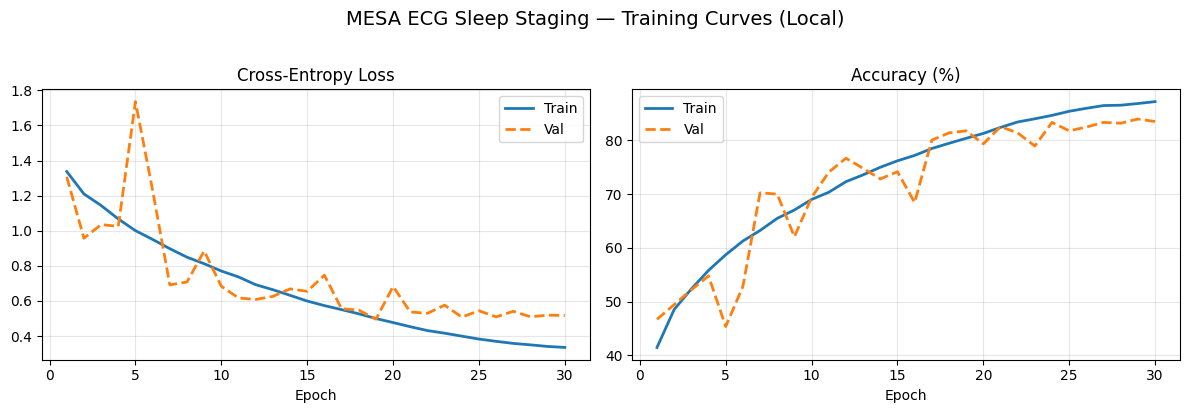

Saved 30/30 epochs → C:\Users\engslm\Desktop\3rd_Biomedical\Signals\Final\Dataset\outputs\training_curves.png


In [10]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — Training Curves (LOCAL)                                  ║
# ║  Plots saved directly to OUTPUT_DIR — no download needed.           ║
# ╚══════════════════════════════════════════════════════════════════════╝
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ✅ Use actual recorded epochs, not the configured max
ep = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep, history['train_loss'], label='Train', linewidth=2)
axes[0].plot(ep, history['val_loss'],   label='Val',   linewidth=2, linestyle='--')
axes[0].set_title('Cross-Entropy Loss');  axes[0].set_xlabel('Epoch')
axes[0].legend();  axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, history['train_acc'], label='Train', linewidth=2)
axes[1].plot(ep, history['val_acc'],   label='Val',   linewidth=2, linestyle='--')
axes[1].set_title('Accuracy (%)');  axes[1].set_xlabel('Epoch')
axes[1].legend();  axes[1].grid(True, alpha=0.3)

plt.suptitle('MESA ECG Sleep Staging — Training Curves (Local)', fontsize=14, y=1.02)
plt.tight_layout()

save_path = os.path.join(CFG['OUTPUT_DIR'], 'training_curves.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {len(ep)}/{CFG["EPOCHS"]} epochs → {save_path}')

## Cell 11 — Evaluation on Test Set

── Per-Class Report ──
              precision    recall  f1-score   support

        Wake     0.9588    0.9192    0.9386       557
          N1     0.4217    0.3723    0.3955        94
          N2     0.7896    0.8471    0.8173       412
          N3     0.6818    0.6897    0.6857        87
         REM     0.8140    0.8333    0.8235       126

    accuracy                         0.8315      1276
   macro avg     0.7332    0.7323    0.7321      1276
weighted avg     0.8314    0.8315    0.8308      1276

Overall Accuracy : 83.15%
Cohen's Kappa    : 0.7544


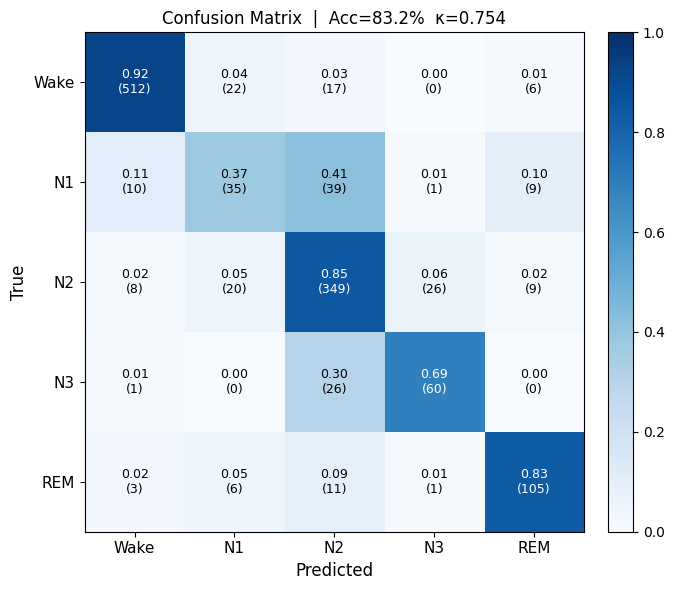

Saved: C:\Users\engslm\Desktop\3rd_Biomedical\Signals\Final\Dataset\outputs\confusion_matrix.png


In [11]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — Test Set Evaluation (LOCAL)                              ║
# ║  Loads best checkpoint → inference → metrics + confusion matrix.    ║
# ║  Identical logic to Colab; outputs saved to OUTPUT_DIR.             ║
# ╚══════════════════════════════════════════════════════════════════════╝

model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb.to(DEVICE))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_true.extend(yb.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

print('── Per-Class Report ──')
print(classification_report(all_true, all_preds, target_names=CLASS_NAMES, digits=4))

overall_acc = (all_preds == all_true).mean() * 100
kappa       = cohen_kappa_score(all_true, all_preds)
print(f'Overall Accuracy : {overall_acc:.2f}%')
print(f"Cohen's Kappa    : {kappa:.4f}")

# Confusion matrix
cm      = confusion_matrix(all_true, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(5));  ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_yticks(range(5));  ax.set_yticklabels(CLASS_NAMES, fontsize=11)
ax.set_xlabel('Predicted', fontsize=12);  ax.set_ylabel('True', fontsize=12)
ax.set_title(f'Confusion Matrix  |  Acc={overall_acc:.1f}%  κ={kappa:.3f}', fontsize=12)
for i in range(5):
    for j in range(5):
        color = 'white' if cm_norm[i,j] > 0.55 else 'black'
        ax.text(j, i, f'{cm_norm[i,j]:.2f}\n({cm[i,j]})',
                ha='center', va='center', fontsize=9, color=color)
plt.tight_layout()

cm_path = os.path.join(CFG['OUTPUT_DIR'], 'confusion_matrix.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {cm_path}')

## Cell 12 — Save Model Locally
Saves to `OUTPUT_DIR`. No browser download — files are already on your machine.

In [12]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — Save Model (LOCAL)                                       ║
# ║  Purpose : Save full checkpoint with weights + config + history.    ║
# ║                                                                      ║
# ║  KEY DIFFERENCE from Colab:                                         ║
# ║    No google.colab.files.download() — files are already local.     ║
# ║    No Drive mounting needed.                                        ║
# ║    Files persist between kernel restarts (unlike Colab /content).   ║
# ╚══════════════════════════════════════════════════════════════════════╝

SAVE_PATH = os.path.join(CFG['OUTPUT_DIR'], 'mesa_ecg_resnet34_local.pt')

torch.save({
    'model_state_dict' : model.state_dict(),
    'cfg'              : CFG,
    'class_names'      : CLASS_NAMES,
    'best_val_acc'     : best_val_acc,
    'history'          : history,
    'samples_per_epoch': SAMPLES_PER_EPOCH,
}, SAVE_PATH)

print(f'Model saved to: {SAVE_PATH}')
print(f'All outputs in: {CFG["OUTPUT_DIR"]}')

# List everything saved
print('\n── Output files ──')
for f in os.listdir(CFG['OUTPUT_DIR']):
    fpath = os.path.join(CFG['OUTPUT_DIR'], f)
    size  = os.path.getsize(fpath) / 1e6
    print(f'  {f:45s}  {size:.1f} MB')

# ── Reload example ────────────────────────────────────────────────────────────
print('\n── Reload example ──')
ckpt = torch.load(SAVE_PATH, map_location='cpu')
new_model = ResNet1D(in_channels=1, num_classes=5)
new_model.load_state_dict(ckpt['model_state_dict'])
new_model.eval()
print(f'Reloaded — best val acc: {ckpt["best_val_acc"]:.2f}%')

Model saved to: C:\Users\engslm\Desktop\3rd_Biomedical\Signals\Final\Dataset\outputs\mesa_ecg_resnet34_local.pt
All outputs in: C:\Users\engslm\Desktop\3rd_Biomedical\Signals\Final\Dataset\outputs

── Output files ──
  best_model.pt                                  29.5 MB
  confusion_matrix.png                           0.1 MB
  mesa_ecg_resnet34_local.pt                     29.6 MB
  training_curves.png                            0.1 MB

── Reload example ──
Reloaded — best val acc: 83.93%


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 1. لازم نحدد الـ Criterion (نفس اللي استخدمته في التدريب، غالباً CrossEntropyLoss)
criterion = torch.nn.CrossEntropyLoss() 

model.eval()
running_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        
        outputs = model(xb)
        
        # 2. حساب الـ Loss لهذه الدفعة
        loss = criterion(outputs, yb)
        running_loss += loss.item() # جمع قيمة الـ loss
        
        _, predicted = torch.max(outputs.data, 1)
        total += yb.size(0)
        correct += (predicted == yb).sum().item()

# 3. حساب المتوسط النهائي
average_loss = running_loss / len(test_loader)
accuracy = 100 * correct / total

print(f'Test Loss: {average_loss:.4f}')
print(f'Test Accuracy: {accuracy:.2f}%')

Test Loss: 0.5792
Test Accuracy: 83.15%
